In [23]:
# Other Packages
import pandas as pd
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
#Oracle Package

try:
    %pip install --user "oracledb" --no-warn-script-location
except Exception as e:
    print("\x1b[31m\u2717 Unexpected error! Please contact course staff\n" +
         "Please include the entire text above and below in your message.")
    raise

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Read SQL File

import oracledb

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_haydenh7", password="a55946628", dsn=dsn)

cur = connection.cursor()

# read the SQL file
with open("insert_data_v2.sql", "r") as file:
    sql_script = file.read()

# split SQL statements
statements = sql_script.split(";")

# execute each statement and throw error if there is a sql statement error
for i, stmt in enumerate(statements, start=1):
    stmt = stmt.strip()
    if stmt:
        try:
            cur.execute(stmt)
        except Exception as e:
            print(f"Skipping error at statement {i}: {e} at {stmt}")

connection.commit()



In [14]:
#Query SQL data and put into pandas dataframe


sql_query = "SELECT danceability, speechiness, track_popularity FROM SPOTIFY_SONGS"

rq2_df = pd.read_sql(sql_query, connection)

rq2_df.head


/tmp/ipykernel_1226/563032739.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rq2_df = pd.read_sql(sql_query, connection)


<bound method NDFrame.head of       DANCEABILITY  SPEECHINESS  TRACK_POPULARITY
0            0.831       0.0460                88
1            0.876       0.4260                87
2            0.729       0.0666                82
3            0.706       0.0324                78
4            0.796       0.1470                83
...            ...          ...               ...
1994         0.204       0.0420                43
1995         0.432       0.0349                42
1996         0.303       0.0335                38
1997         0.285       0.0295                59
1998         0.512       0.0583                45

[1999 rows x 3 columns]>

In [22]:
#Fit a linear model and print coefs

X = rq2_df[['DANCEABILITY', 'SPEECHINESS']]
y = rq2_df['TRACK_POPULARITY']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 36.67218399872749
Coefficients: [26.65185697 33.17585082]


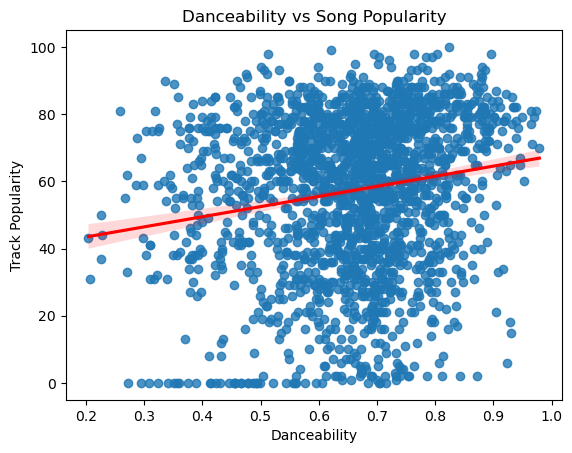

In [28]:
#Plot of Danceability vs Track Popularity

sns.regplot(
    x="DANCEABILITY",
    y="TRACK_POPULARITY",
    data=rq2_df,
    line_kws={"color":"red"}
)

plt.title("Danceability vs Song Popularity")
plt.xlabel("Danceability")
plt.ylabel("Track Popularity")

plt.show()

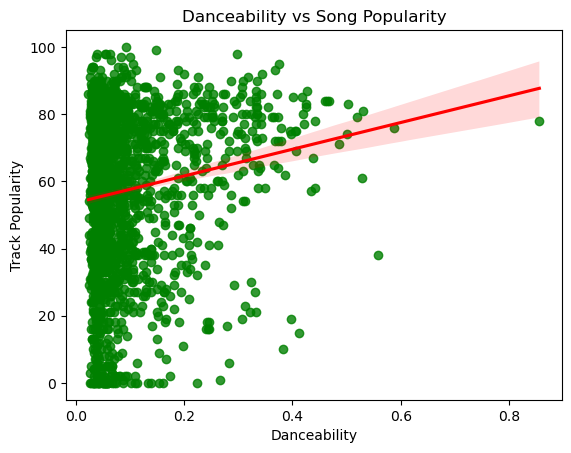

In [31]:
#Plot of Speechiness vs Track Popularity

sns.regplot(
    x="SPEECHINESS",
    y="TRACK_POPULARITY",
    data=rq2_df,
    line_kws={"color":"red"},
    scatter_kws={"color": "green"}
)

plt.title("Danceability vs Song Popularity")
plt.xlabel("Danceability")
plt.ylabel("Track Popularity")

plt.show()